In [3]:
import pandas as pd
import numpy as np
df1 = pd.read_csv("train.csv")
df2 = pd.read_csv("test.csv")
df3 = pd.read_csv("gender_submission.csv")
df_all= pd.merge(df2,df3,on="PassengerId",how="outer")

In [4]:
cols=list(df_all.columns)

In [5]:
col=cols.pop(11)
cols.insert(1,col)
df_all = df_all[cols]

In [6]:
df = pd.concat([df1,df_all],ignore_index = True)

In [7]:

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [8]:
df[["PassengerId","Survived","Pclass","Name","Sex","Age","SibSp","Parch","Ticket","Fare","Cabin","Embarked"]].drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [9]:
df.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,False,False,False,False,False,True,False,False,False,False,True,False
1305,False,False,False,False,False,False,False,False,False,False,False,False
1306,False,False,False,False,False,False,False,False,False,False,True,False
1307,False,False,False,False,False,True,False,False,False,False,True,False


In [10]:
df.isna().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [11]:
df["Age"].dtype

dtype('float64')

In [12]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode().iloc[0])

In [13]:
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [14]:
df["Name"].str.contains(r"^\s|\s$", na=False).sum()


np.int64(4)

In [15]:
df[df["Name"].str.contains(r"^\s|\s$", na=False)]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.00,NaN,S
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.55,E17,S
1166,1167,1,2,"Bryhl, Miss. Dagmar Jenny Ingeborg",female,20.0,1,0,236853,26.00,NaN,S
1221,1222,1,2,"Davies, Mrs. John Morgan (Elizabeth Agnes Mary...",female,48.0,0,2,C.A. 33112,36.75,NaN,S


In [16]:
df["Name"] = df["Name"].str.strip()


In [17]:
df["Sex"].str.contains(r"^\s|\s$", na=False).sum()

np.int64(0)

In [18]:
df["Ticket"].str.contains(r"^\s|\s$", na=False).sum()

np.int64(0)

In [19]:
df[(df["Age"] < 0) | (df["Age"] > 100)]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [20]:
df["Fare"].isnull().sum()

np.int64(1)

In [21]:
df[df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [22]:

df["Fare"]=df["Fare"].fillna(0)

In [23]:
df[df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [24]:
df["Cabin"].isna().sum()

np.int64(1014)

In [25]:
df["Survived"].sum()

np.int64(494)

In [39]:
df.groupby("Sex")["Survived"].agg(["sum", "count", "mean"])
df_SEX =df.groupby("Sex")["Survived"]

In [27]:
df.groupby("Pclass")["Survived"].agg(["sum", "count", "mean"])

,sum,count,mean
Pclass,,,
1,186,323,0.575851
2,117,277,0.422383
3,191,709,0.269394


In [28]:
df.groupby("Embarked")["Survived"].agg(["sum", "count", "mean"])

,sum,count,mean
Embarked,,,
C,133,270,0.492593
Q,54,123,0.439024
S,307,916,0.335153


In [29]:
max_age = int(df["Age"].max()) + 10
bins = np.arange(0,max_age,10)

In [30]:
df["AgeGroup"] = pd.cut(df["Age"],bins =bins)

In [31]:
df.groupby("AgeGroup")["Survived"].agg(["sum", "count", "mean"])


C:\Users\User\AppData\Local\Temp\ipykernel_25852\1158483342.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].agg(["sum", "count", "mean"])


,sum,count,mean
AgeGroup,,,
"(0, 10]",48,86,0.558140
"(10, 20]",66,162,0.407407
"(20, 30]",129,361,0.357341
"(30, 40]",89,210,0.423810
"(40, 50]",48,132,0.363636
"(50, 60]",28,62,0.451613
"(60, 70]",7,27,0.259259
"(70, 80]",2,6,0.333333


In [32]:
df[(df["Survived"] == 1) & (df["SibSp"] > 0)].shape[0]



196

In [33]:
df[(df["Survived"] == 1) & (df["Parch"] > 0)].shape[0]

162

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

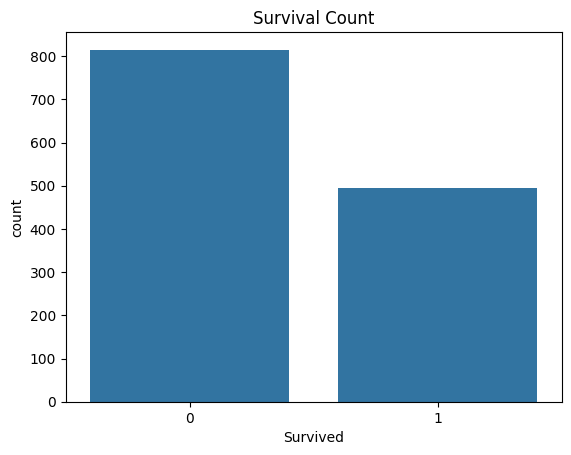

In [35]:
sns.countplot(data=df,x="Survived")
plt.title("Survival Count")
plt.show()

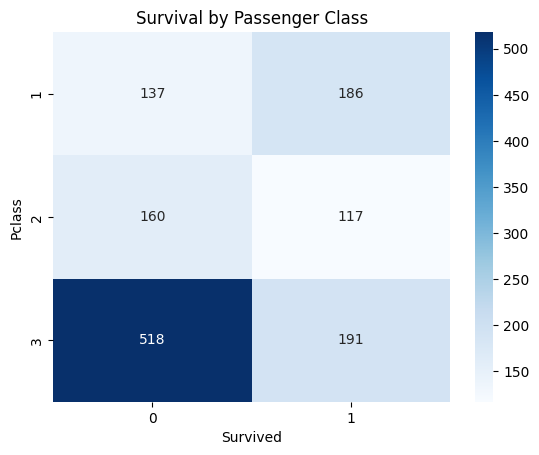

In [43]:
import seaborn as sns

heatmap_data = pd.crosstab(df["Pclass"], df["Survived"])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Survival by Passenger Class")
plt.show()


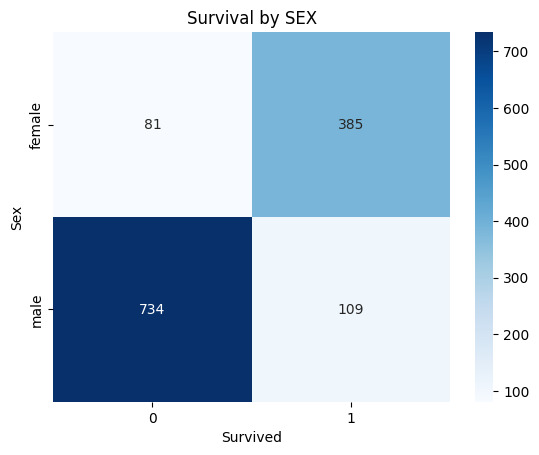

In [50]:
import seaborn as sns

heatmap_data = pd.crosstab(df["Sex"], df["Survived"])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Survival by SEX")
plt.show()


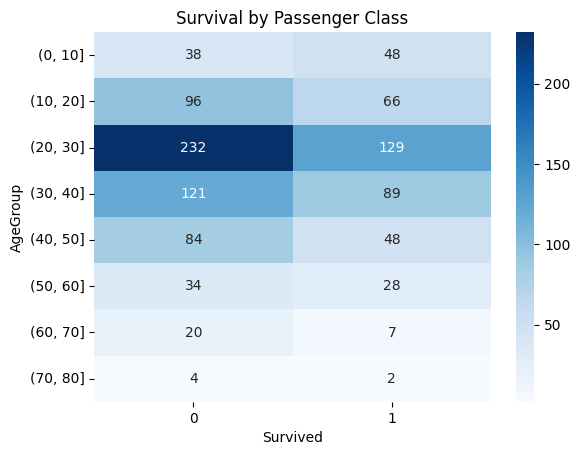

In [48]:
import seaborn as sns

heatmap_data = pd.crosstab(df["AgeGroup"], df["Survived"])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Survival by Age Group")
plt.show()


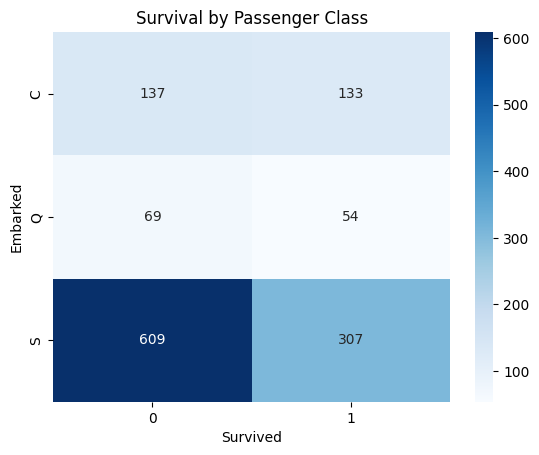

In [49]:
import seaborn as sns

heatmap_data = pd.crosstab(df["Embarked"], df["Survived"])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues")
plt.title("Survival by Embarked")
plt.show()


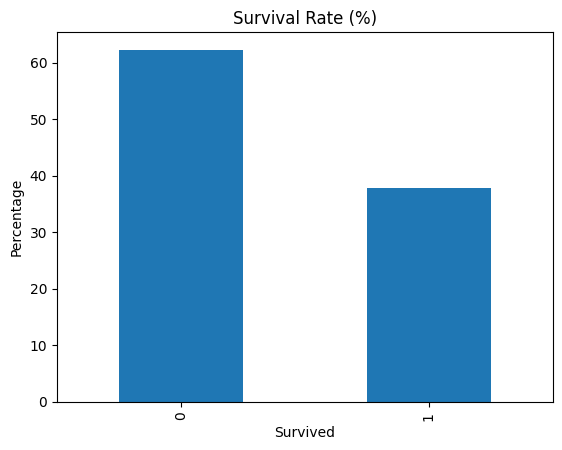

In [51]:
(df["Survived"].value_counts(normalize=True) * 100).plot(kind="bar")
plt.title("Survival Rate (%)")
plt.ylabel("Percentage")
plt.show()


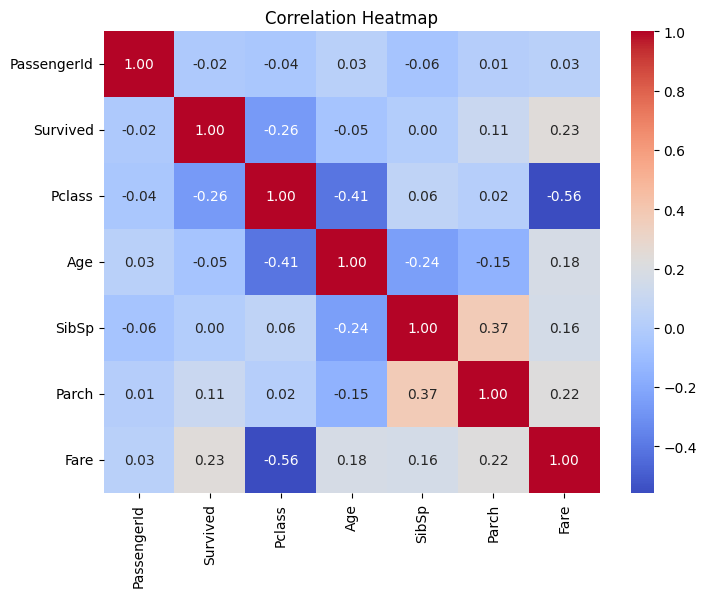

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# calculate correlation matrix
corr = df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
